In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def filter_grasslands(input_file, output_file):
    # Open the MODIS data file
    with rasterio.open(input_file) as src:
        data = src.read(1)

        # Define the coordinates for the Arctic Circle (approximately 66.5 degrees north)
        arctic_circle_latitude = 66.5
        arctic_circle_y = int((90 - arctic_circle_latitude) / (180 / data.shape[0]))

        # Remove the Arctic Circle
        data[:arctic_circle_y, :] = 0

        # Filter for grasslands (value 10)
        grasslands = np.where(data == 10, 10, 0)

        # Save the result to a new file
        profile = src.profile
        with rasterio.open(output_file, 'w', **profile) as dst:
            dst.write(grasslands.astype(rasterio.uint8), 1)

        # Plot the result
        plt.imshow(grasslands, cmap='Greens')
        plt.title('Grasslands (excluding Arctic Circle)')
        plt.show()

In [3]:
MODIS_LANDCOVER_RASTER = '../../../data/processed/MCD12C1-2010-epsg.tif'
MODIS_LANDCOVER_NOARCTIC_RASTER = '../../../data/processed/MCD12C1-2010-epsg-noarctic.tif'

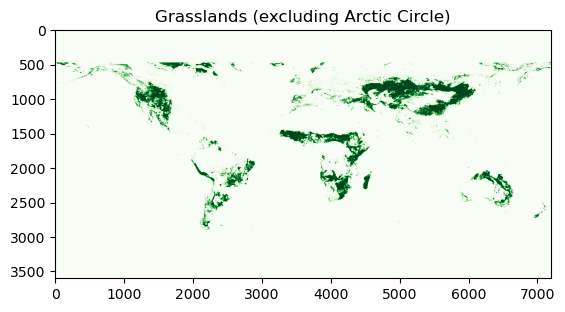

In [4]:
filter_grasslands(MODIS_LANDCOVER_RASTER, MODIS_LANDCOVER_NOARCTIC_RASTER)

In [5]:
with rasterio.open(MODIS_LANDCOVER_RASTER) as src:
    data = src.read(1)
    no_data_value = src.nodatavals

In [6]:
# Print no data value from metadata
print(f"No data value from metadata: {no_data_value}")


unique_values = set(np.unique(data))
print(f"Unique values in the data: {unique_values}")


No data value from metadata: (255.0,)
Unique values in the data: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16}


In [7]:
with rasterio.open(MODIS_LANDCOVER_NOARCTIC_RASTER) as src:
    data = src.read(1)
    no_data_value = src.nodatavals

# Print no data value from metadata
print(f"No data value from metadata: {no_data_value}")

unique_values = set(np.unique(data))
print(f"Unique values in the data: {unique_values}")


No data value from metadata: (255.0,)
Unique values in the data: {0, 10}
